# 加州住房价格回归任务（California Housing Regression）

本 Notebook 演示如何使用 PyTorch 构建一个全连接神经网络（MLP）来解决**回归问题**。  
以加州住房价格数据集为例，涵盖以下完整流程：

1. 环境配置（库导入与设备检测）
2. 数据准备（加载、划分、标准化、Dataset、DataLoader）
3. 模型构建（网络定义、参数统计、早停、评估、训练）
4. 模型评估与测试（测试集 MSE 评估）

## 一、环境配置

导入所有必要的第三方库，检测并配置计算设备（CPU 或 GPU），为后续训练做好准备。

In [84]:
import matplotlib as mpl           # 导入 matplotlib 核心模块，用于图形后端配置
import matplotlib.pyplot as plt    # 导入绘图子模块，提供 plot/show 等绘图函数
%matplotlib inline                 
# Jupyter 魔法命令：将图表内嵌显示在 notebook 中，无需调用 show()
import numpy as np                 # 导入 NumPy，用于高效的数值计算和多维数组操作
import sklearn                     # 导入 scikit-learn，提供数据集、预处理、评估等机器学习工具
import pandas as pd                # 导入 Pandas，用于数据读取、操作与分析（DataFrame/Series）
import os                          # 导入 os 模块，用于文件路径操作和系统调用
import sys                         # 导入 sys 模块，用于获取 Python 运行时信息（版本、路径等）
import time                        # 导入 time 模块，用于计时
from tqdm import tqdm         # 导入 tqdm 进度条库，auto 版本可自动适配 notebook 和终端显示
import torch                       # 导入 PyTorch 深度学习框架主包
import torch.nn as nn              # 导入神经网络模块，包含层定义（Linear/ReLU）和损失函数
import torch.nn.functional as F    # 导入函数式接口，包含激活函数、池化等无参数操作

# sys.version_info：返回 Python 版本的具名元组，各字段含义如下：
#   major        —— 主版本号（如 3）
#   minor        —— 次版本号（如 9）
#   micro        —— 微版本号（如 17）
#   releaselevel —— 发布阶段（如 'final'/'beta'/'candidate'）
#   serial       —— 发行序号（如 0）
print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:  # 遍历所有主要依赖库
    print(module.__name__, module.__version__)  # 打印库名和版本号，用于环境验证与复现

# torch.cuda.is_available()：检测当前环境是否有可用 GPU
# torch.device("cuda:0")：使用第一块 GPU；torch.device("cpu")：使用 CPU
# 返回值 device (torch.device)：后续张量和模型都需要移到此设备上进行计算
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的计算设备（cpu 或 cuda:0）


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、准备数据

完成从原始数组到可供 PyTorch 训练的 `DataLoader` 的全流程数据准备，包括加载、划分、标准化、封装 Dataset 和 DataLoader。

### 2.1 数据集加载与探索

使用 `sklearn.datasets.fetch_california_housing` 加载加州住房价格数据集，了解数据规模、特征含义与标签分布。

In [85]:
from sklearn.datasets import fetch_california_housing  # 从 sklearn 导入加州住房数据集加载函数

# fetch_california_housing：加载加州住房价格回归数据集
# 参数 data_home (str)：本地缓存目录，若文件不存在则自动从网络下载
# 返回值 housing (Bunch)：类字典对象，主要字段：
#   .data   (ndarray, shape=[20640, 8])：8个特征（收入/房龄/房间数/卧室数/人口/户均人数/纬度/经度）
#   .target (ndarray, shape=[20640,])：目标变量，房价中位数（单位：十万美元）
#   .DESCR  (str)：数据集文字说明
housing = fetch_california_housing(data_home='data')
print(housing.DESCR)          # 打印数据集的完整文字描述，介绍各特征含义和数据来源
print(housing.data.shape)     # 打印特征矩阵形状：(20640, 8)，共 20640 个样本，8 个特征
print(housing.target.shape)   # 打印标签向量形状：(20640,)，每个样本对应一个连续的房价值

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [86]:
# print(housing.data[0:5])
import pprint  # 导入 pprint（pretty-print）模块，对复杂数据结构（如多维数组）进行格式化输出，比 print 更易读

# pprint.pprint：格式化打印对象
# 参数 housing.data[0:2]（ndarray, shape=[2, 8]）：取前2个样本的8维特征向量
# 每行代表一个样本，8个列分别是：收入/房龄/平均房间数/平均卧室数/人口/平均入住人数/纬度/经度
pprint.pprint(housing.data[0:2])
print('-' * 50)  # 打印分隔线（50个'-'），便于视觉上区分特征和标签
# pprint.pprint：格式化打印前2个样本的标签值
# housing.target[0:2]（ndarray, shape=[2,]）：前2个样本的房价（单位：十万美元）
pprint.pprint(housing.target[0:2])

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02]])
--------------------------------------------------
array([4.526, 3.585])


### 2.2 划分训练集、验证集与测试集

将数据集按比例划分为三部分：
- **训练集**：用于模型参数更新（约 56%）
- **验证集**：用于超参数调整和早停判断（约 19%）
- **测试集**：最终评估模型泛化性能，训练过程中不可见（约 25%）

In [87]:
from sklearn.model_selection import train_test_split  # 导入数据集划分函数

# train_test_split：随机将数据集划分为训练集和测试集
# 参数 housing.data (ndarray, shape=[20640, 8])：特征矩阵
# 参数 housing.target (ndarray, shape=[20640,])：标签向量
# 参数 random_state (int=7)：随机种子，确保每次运行划分结果完全一致（可复现性）
# 返回：默认 75% 训练、25% 测试；x_train_all(15480,8)，x_test(5160,8)
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state=7)
# 再次划分：从 x_train_all 中切分出验证集（用于训练时监控模型，防止过拟合）
# 参数 random_state (int=11)：不同种子保证与上次切分不同
# 返回：x_train(11610,8)，x_valid(3870,8)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state=11)
# 打印训练集形状：(11610, 8) 特征 和 (11610,) 标签
print(x_train.shape, y_train.shape)
# 打印验证集形状：(3870, 8) 特征 和 (3870,) 标签
print(x_valid.shape, y_valid.shape)
# 打印测试集形状：(5160, 8) 特征 和 (5160,) 标签
print(x_test.shape, y_test.shape)

# 用字典统一管理三个数据集，key 为字符串名称，value 为 [特征, 标签] 列表
# 方便后续通过 mode 字符串按需取用对应数据集
dataset_maps = {
    "train": [x_train, y_train],  # 训练集：用于模型参数更新
    "valid": [x_valid, y_valid],  # 验证集：用于超参数调优和早停判断
    "test":  [x_test,  y_test],   # 测试集：最终评估模型泛化能力（训练过程中不可见）
}  # 把3个数据集都放到字典中，方便 HousingDataset 按名称取用


(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [88]:
type(x_train)  # 查看 x_train 的数据类型：结果为 numpy.ndarray（NumPy 数组）
# 说明 sklearn 返回的数据是原生 ndarray 类型，不是 PyTorch Tensor
# 后续在 HousingDataset 中需要用 torch.from_numpy() 将其转换为 Tensor

numpy.ndarray

### 2.3 数据标准化（StandardScaler）

对输入特征进行 Z-score 标准化（均值为 0，标准差为 1），消除不同特征量纲差异，加快梯度下降收敛。  
**注意：只能用训练集 `fit`，验证集和测试集只做 `transform`，避免数据泄露。**

In [89]:
from sklearn.preprocessing import StandardScaler  # 导入标准化类，对特征进行 Z-score 归一化

# StandardScaler：对每个特征独立进行标准化，使其均值为 0、标准差为 1
# 公式：z = (x - mean) / std
# 标准化的意义：消除不同特征量纲的差异，加速梯度下降收敛，提高模型训练稳定性
scaler = StandardScaler()  # 实例化标准化器，此时未计算任何统计量

# scaler.fit(x_train)：仅用训练集计算每个特征的均值（mean_）和标准差（scale_），并保存到 scaler 中
# 参数 x_train (ndarray, shape=[11610, 8])：训练集特征矩阵
# 返回值：scaler 本身（便于链式调用）
# 重要：必须只用训练集 fit，不能用验证集/测试集，否则会造成数据泄露（test data leakage）
# 区别：fit() 只计算统计量；transform() 只做变换；fit_transform() = fit() + transform() 连续执行
# 这里用 _ 接收 fit() 的返回值，避免 Jupyter 自动渲染 StandardScaler 的 HTML 表示时触发 Windows GBK 解码错误
_ = scaler.fit(x_train)  # fit 负责计算均值和方差；fit_transform 是先 fit 再 transform

In [90]:
# 演示 0 维数组（标量）的 shape 属性
# np.array(1)：创建一个 0 维 NumPy 数组（标量数组），其值为整数 1
# .shape：返回数组的形状，0 维数组的 shape 是空元组 ()
# 对比：np.array([1]).shape = (1,)  →  1 维长度为 1 的数组
#       np.array(1).shape  = ()     →  0 维标量数组，没有任何维度
# 意义：了解 shape=() 有助于理解标量张量与向量张量的区别，
#       以及 reshape(-1,1) 等操作的必要性（将 1D 标签转为 2D 列向量）
np.array(1).shape

()

### 2.4 构建自定义数据集（HousingDataset）

继承 `torch.utils.data.Dataset`，封装标准化后的特征与标签，实现 `__len__` 和 `__getitem__` 接口，使数据可直接传入 `DataLoader`。

In [91]:
# 自定义 PyTorch 数据集类，需继承 torch.utils.data.Dataset 抽象基类
# 好处：统一接口，可直接传入 DataLoader 进行批量加载
from torch.utils.data import Dataset  # 导入 Dataset 抽象基类，必须继承它并实现 __len__ 和 __getitem__
# from torch.utils import data

class HousingDataset(Dataset):
    def __init__(self, mode='train'):
        """
        初始化数据集，加载并预处理指定模式的数据
        参数 mode (str)：数据集模式，可选 'train'/'valid'/'test'，默认 'train'
        """
        self.x, self.y = dataset_maps[mode]  # 从字典中取对应数据，x/y 均为 ndarray 类型
        # scaler.transform(self.x)：用训练集统计量对数据标准化，返回 ndarray，shape=[N, 8]
        # torch.from_numpy(...)：将 ndarray 转换为 PyTorch Tensor（共享内存，零拷贝）
        # .float()：将 Tensor 数据类型转为 float32（PyTorch 默认浮点精度，适合神经网络计算）
        self.x = torch.from_numpy(scaler.transform(self.x)).float()  # shape: [N, 8]
        # self.y 原始 shape: (N,) → reshape(-1, 1) 变为 [N, 1]
        # 原因：回归模型输出 shape=[batch_size, 1]，标签需与输出维度匹配才能计算 MSE 损失
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)  # shape: [N, 1]

    def __len__(self):  # 必须实现，DataLoader 用此方法确定数据集大小
        return len(self.x)  # 返回样本总数（int），即 x 第 0 维的大小

    def __getitem__(self, idx):  # 必须实现，支持整数索引和切片索引
        """
        按索引取样本
        参数 idx (int 或 slice)：样本索引或切片
        返回值：(x_sample, y_sample) 元组
            - x_sample (Tensor, shape=[8] )：标准化后的特征向量
            - y_sample (Tensor, shape=[1] )：对应的房价标签
        """
        return self.x[idx], self.y[idx]

# 分别构建训练集、验证集、测试集的 Dataset 对象
# 与 torchvision 数据集（如 FashionMNIST）接口完全一致，可直接传入 DataLoader
train_ds = HousingDataset("train")  # 训练集 Dataset，含 11610 个样本
valid_ds = HousingDataset("valid")  # 验证集 Dataset，含 3870 个样本
test_ds  = HousingDataset("test")   # 测试集 Dataset，含 5160 个样本

In [92]:
type(train_ds)  # 查看 train_ds 的类型，结果为 __main__.HousingDataset
# 说明 train_ds 是我们自定义的 HousingDataset 实例，继承自 torch.utils.data.Dataset

__main__.HousingDataset

In [93]:
len(train_ds)  # 调用 HousingDataset.__len__()，返回训练集样本总数
# 返回值 (int)：11610，与 x_train.shape[0] 一致

11610

In [94]:
train_ds[:2]  # 使用切片 slice(0,2) 调用 __getitem__，取前 2 个样本
# 返回值：(x, y) 元组
#   x (Tensor, shape=[2, 8])：2 个样本标准化后的特征向量
#   y (Tensor, shape=[2, 1])：2 个样本对应的房价标签（十万美元）

(tensor([[ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824],
         [-0.2981,  0.3523, -0.1092, -0.2506, -0.0341, -0.0060,  1.0806, -1.0611]]),
 tensor([[3.2260],
         [1.5140]]))

In [95]:
train_ds[0][0]  # train_ds[0] 调用 __getitem__(0)，返回 (x_0, y_0) 元组
# [0] 取元组第一个元素，即第 0 个样本的特征向量
# 返回值 (Tensor, shape=[8])：标准化后的 8 个特征值（中位收入/房龄/房间数/卧室数/人口/户均人数/纬度/经度）

tensor([ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824])

### 2.5 构建数据加载器（DataLoader）

使用 `DataLoader` 对数据集进行批量采样。训练集开启 `shuffle=True` 防止模型记住顺序；验证集与测试集保持顺序以保证评估结果可复现。

In [96]:
from torch.utils.data import DataLoader  # 导入 DataLoader，负责批量采样、打乱顺序、多进程加载等

# batch_size：每个批次送入模型的样本数量，是重要的超参数
# 较大 batch_size → 训练更稳定，但显存占用更多；较小 batch_size → 梯度噪声大，有正则化效果
batch_size = 16  # 每批次 16 个样本

# DataLoader 参数说明：
#   第一个参数 (Dataset)：数据集对象（必须是 Dataset 子类）
#   batch_size (int)：每批次的样本数量
#   shuffle (bool)：是否在每个 epoch 开始前打乱数据顺序
#     - 训练集设为 True：防止模型记住顺序，起到隐式正则化作用
#     - 验证/测试集设为 False：保持顺序，保证评估结果可复现

# train_loader：训练集加载器，每次迭代返回 (x_batch, y_batch)
# x_batch.shape=[16, 8]，y_batch.shape=[16, 1]，共 ⌈11610/16⌉=726 个批次
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
# val_loader：验证集加载器，shuffle=False 保持顺序，共 ⌈3870/16⌉=242 个批次
val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
# test_loader：测试集加载器，shuffle=False；测试集上推理可增大batchsize
test_loader = DataLoader(test_ds, batch_size=batch_size*4, shuffle=False)

## 三、模型构建

定义神经网络结构，统计参数量，并实现早停回调、评估函数与完整训练循环。

### 3.1 神经网络结构定义（NeuralNetwork）

定义一个两层全连接神经网络（MLP）：`Linear(8→30) → ReLU → Linear(30→1)`。  
输出层为 1 个神经元（无激活函数），直接输出预测的连续房价值，适合回归任务。

In [97]:
# 回归任务输出层只需要 1 个神经元，直接输出预测的连续数值（房价）

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        """
        初始化回归神经网络
        参数 input_dim (int)：输入特征维度，默认 8（加州住房数据集的特征数）
        网络结构：Linear(8→30) → ReLU → Linear(30→1)
        """
        super().__init__()  # 必须调用父类 nn.Module 的初始化，完成模块注册等内部操作
        # nn.Sequential：将多个层按顺序组合，前向传播时依次执行每一层
        self.linear_relu_stack = nn.Sequential(
            # nn.Linear(in_features, out_features)：全连接层（线性变换 y = xW^T + b）
            # 参数 input_dim=8：输入维度；30：输出（隐藏层）神经元数
            # 内部参数：权重 W.shape=[30, 8]（参数量 240），偏置 b.shape=[30]（参数量 30）
            nn.Linear(input_dim, 30),
            # nn.ReLU()：整流线性单元激活函数，f(x) = max(0, x)
            # 引入非线性，使网络能拟合复杂函数；无可学习参数
            nn.ReLU(),
            # 输出层：将 30 维隐藏表示映射到 1 维（回归值）
            # 参数量：权重 W.shape=[1, 30]（30）+ 偏置 b.shape=[1]（1）= 31
            nn.Linear(30, 1)
        )

    def forward(self, x):
        """
        前向传播
        参数 x (Tensor, shape=[batch_size, 8])：输入特征批次（标准化后）
        返回值 logits (Tensor, shape=[batch_size, 1])：预测的房价值（回归输出）
        """
        # x.shape [batch size, 8]
        # 依次经过 Linear(8→30) → ReLU → Linear(30→1)，每层自动处理 batch 维度
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 1]，每行是一个样本的预测房价
        return logits

In [98]:
# 手动验证回归网络的总参数量
# 第 1 层 Linear(8 → 30)：
#   权重矩阵 W 的形状为 [30, 8]，参数量 = 8 × 30 = 240
#   偏置向量 b 的形状为 [30]，  参数量 = 30
# 第 2 层 Linear(30 → 1)：
#   权重矩阵 W 的形状为 [1, 30]，参数量 = 30 × 1 = 30
#   偏置向量 b 的形状为 [1]，   参数量 = 1
# 总参数量 = 240 + 30 + 30 + 1 = 301
8 * 30 + 30 + 30 * 1 + 1

301

In [99]:
# 使用 PyTorch API 自动计算模型总参数量（与手动计算验证一致）
# NeuralNetwork()：实例化一个默认配置（input_dim=8）的回归网络
# .parameters()：返回迭代器，遍历模型的所有可学习参数张量（权重 W 和偏置 b）
# p.numel()：返回参数张量 p 中的元素总数（numel = number of elements）
#   例如 W.shape=[30,8] → p.numel() = 240；b.shape=[30] → p.numel() = 30
# sum(...)：将所有参数的 numel 累加，得到总参数量（int）
total_params = sum(p.numel() for p in NeuralNetwork().parameters())
# f-string 格式化输出，{total_params:,} 使用千位分隔符（逗号）格式化大数字，便于阅读
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 301


### 3.2 模型参数统计与结构展示

通过三种方式打印模型结构与各层参数量：树状打印、逐层遍历和逐参数张量遍历。

In [100]:
# 实例化一个模型用于结构展示
model_demo = NeuralNetwork()  # 使用默认参数 input_dim=8 实例化回归网络

# ── 方式一：直接打印模型对象 ─────────────────────────────────────────────────
# print(model)：调用 nn.Module 的 __repr__ 方法，按树状结构展示所有子模块
# 输出格式：模块名称 → 类型 → 构造参数（如 in_features / out_features）
print("=" * 55)
print("【方式一】模型整体结构（树状）")
print("=" * 55)
print(model_demo)  # 显示 NeuralNetwork 的 Sequential 嵌套结构

# ── 方式二：逐层遍历 named_modules ───────────────────────────────────────────
# model.named_modules()：以深度优先顺序返回 (名称, 模块) 迭代器
#   - 名称 (str)：模块路径，顶层为 ''，子层为 'linear_relu_stack.0' 等
#   - 模块 (nn.Module)：对应的层对象
# module.__class__.__name__：获取层的类名字符串，如 'Linear' / 'ReLU'
print("\n" + "=" * 55)
print("【方式二】逐层详细信息（含参数量）")
print("=" * 55)
print(f"{'层名':<28} {'类型':<12} {'参数量':>8}")
print("-" * 55)
for name, module in model_demo.named_modules():
    if name == "":          # 跳过顶层容器本身（名称为空字符串的根模块）
        continue
    # sum(p.numel() for p in module.parameters(recurse=False))
    #   recurse=False：只统计该层自身的参数，不递归统计子层（避免重复计数）
    #   p.numel()：返回参数张量的元素总数（int）
    param_count = sum(p.numel() for p in module.parameters(recurse=False))
    # f-string 对齐格式：层名左对齐 28 字符，类型左对齐 12 字符，参数量右对齐 8 字符
    print(f"{name:<28} {module.__class__.__name__:<12} {param_count:>8,}")

# ── 方式三：逐个参数张量遍历 named_parameters ─────────────────────────────────
# model.named_parameters()：返回 (参数全路径名, 参数张量) 迭代器
#   - 名称 (str)：如 'linear_relu_stack.0.weight' / 'linear_relu_stack.0.bias'
#   - 参数 (nn.Parameter)：Tensor 子类，shape 表示权重/偏置的维度
#   - requires_grad (bool)：是否参与梯度更新，可学习参数均为 True
print("\n" + "=" * 55)
print("【方式三】所有可学习参数张量（含 shape）")
print("=" * 55)
print(f"{'参数名称':<40} {'形状':<18} {'元素数':>8}")
print("-" * 55)
total = 0  # 累计总参数量
for param_name, param in model_demo.named_parameters():
    count = param.numel()   # 当前参数张量的元素总数（int）
    total += count          # 累加到总参数量
    # param.shape (torch.Size)：张量各维度大小，如 torch.Size([30, 8])
    print(f"{param_name:<40} {str(list(param.shape)):<18} {count:>8,}")
print("-" * 55)
# 最终汇总行：输出全部可学习参数的数量
print(f"{'合计':<40} {'':<18} {total:>8,}")

【方式一】模型整体结构（树状）
NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=1, bias=True)
  )
)

【方式二】逐层详细信息（含参数量）
层名                           类型                参数量
-------------------------------------------------------
linear_relu_stack            Sequential          0
linear_relu_stack.0          Linear            270
linear_relu_stack.1          ReLU                0
linear_relu_stack.2          Linear             31

【方式三】所有可学习参数张量（含 shape）
参数名称                                     形状                      元素数
-------------------------------------------------------
linear_relu_stack.0.weight               [30, 8]                 240
linear_relu_stack.0.bias                 [30]                     30
linear_relu_stack.2.weight               [1, 30]                  30
linear_relu_stack.2.bias                 [1]                       1
--------------------------------------

### 3.3 早停回调类（EarlyStopCallback）

早停（Early Stopping）是一种防止过拟合的正则化技巧：当验证集指标在连续多轮内不再改善时，提前终止训练。

In [101]:
class EarlyStopCallback:
    """
    早停回调类（Early Stopping）
    功能：当验证集评估指标在连续若干轮次内不再改善时，提前终止训练，防止过拟合
    使用方式：每次评估后调用实例（callback(metric)），再通过 .early_stop 属性判断是否停止
    """
    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化早停回调
        参数 patience (int)：允许指标不改善的最大连续轮次，默认 5。
             超过此轮次无改善则触发早停。
        参数 min_delta (float)：判定"有改善"的最小变化量，默认 0.01。
             若指标提升幅度 < min_delta，则认为没有实质性改善。
        """
        self.patience = patience      # 最大容忍轮次（超参数）
        self.min_delta = min_delta    # 最小改善阈值（超参数）
        self.best_metric = -1         # 历史最佳指标值，初始化为 -1（适用于越大越好的指标，如 -loss/acc）
        self.counter = 0              # 连续未改善轮次的计数器，达到 patience 时触发早停

    def __call__(self, metric):
        """
        每次验证结束后调用，更新早停状态
        参数 metric (float)：当前轮次的评估指标（越大越好）
             - 对于准确率：直接传入 acc
             - 对于损失：传入 -loss（取负使其变为越大越好）
        """
        if metric >= self.best_metric + self.min_delta:
            # 指标有显著改善：更新最佳记录并重置计数器
            self.best_metric = metric  # 更新历史最佳指标
            self.counter = 0           # 重置计数器
        else:
            self.counter += 1  # 未改善：计数器加 1

    @property
    def early_stop(self):
        """
        判断是否触发早停（只读属性）
        返回值 (bool)：若连续未改善轮次 >= patience，则返回 True，应停止训练
        """
        return self.counter >= self.patience


### 3.4 评估函数（回归任务）

回归任务的评估只需计算验证集上的平均 MSE 损失，无需计算分类准确率。

In [ ]:

# @torch.no_grad()：装饰器，在此函数内关闭梯度跟踪
# 评估时不需要反向传播，关闭梯度计算可节省约 50% 的显存，并加速推理
@torch.no_grad()
def evaluating(model, dataloader, loss_fct,optimizer):
    """
    回归模型评估函数（仅计算平均损失，不计算分类准确率）
    参数 model (nn.Module)：待评估的神经网络模型（需已切换到 eval 模式）
    参数 dataloader (DataLoader)：评估数据的加载器（验证集或测试集）
    参数 loss_fct (nn.Module)：损失函数，此处为 nn.MSELoss()
    返回值 (float)：所有批次 MSE 损失值的均值，代表模型在整个数据集上的回归误差
    """
    model.eval()  # 切换到评估模式（停用 Dropout、BatchNorm，确保推理过程一致且无随机性，通常在验证/测试阶段调用）
    optimizer.zero_grad(set_to_none=True)   # 释放残余梯度，释放显存空间；set_to_none=True 释放显存，提高推理阶段的显存利用率
    loss_list = []  # 存储每个批次的损失值（Python float 列表）
    for datas, labels in dataloader:  # 逐批次遍历整个数据集
        datas = datas.to(device)    # 将特征批次移到计算设备（GPU 或 CPU）
        labels = labels.to(device)  # 将标签批次移到同一计算设备
        # 前向计算：将特征输入模型，得到预测房价
        logits = model(datas)       # shape=[batch_size, 1]，每行是一个预测值
        loss = loss_fct(logits, labels)  # 计算当前批次的 MSE 损失，结果为标量 Tensor
        loss_list.append(loss.item())    # .item()：将标量 Tensor 转为 Python float，存入列表

    # np.mean(loss_list)：计算所有批次损失的算术平均值
    # 返回值类型：float，代表整个验证/测试集上的平均 MSE 损失
    return np.mean(loss_list)


### 3.5 训练函数与训练流程

封装完整的训练循环，包括：前向传播、损失计算、反向传播、参数更新、验证集评估和早停判断。

In [103]:
# 训练主函数：封装完整训练流程（前向传播→损失计算→反向传播→参数更新→验证→早停）
def training(
    model,                     # nn.Module：待训练的神经网络模型
    train_loader,              # DataLoader：训练集加载器
    val_loader,                # DataLoader：验证集加载器
    epoch,                     # int：最大训练轮次数（outer loop 次数）
    loss_fct,                  # nn.Module：损失函数（回归用 MSELoss）
    optimizer,                 # torch.optim.Optimizer：参数优化器（如 SGD）
    early_stop_callback=None,  # EarlyStopCallback 或 None：早停回调，None 表示不使用早停
    eval_step=500,             # int：每隔多少步（batch）进行一次验证集评估
    ):
    # record_dict：记录训练全过程的指标，用于后续绘图分析
    record_dict = {
        "train": [],  # 每元素为 {'loss': float, 'step': int}，训练集每步的损失
        "val":   []   # 每元素为 {'loss': float, 'step': int}，验证集每隔 eval_step 步的损失
    }

    global_step = 0   # 全局步数计数器，每处理一个 batch（批次）加 1
    model.train()     # 将模型设置为训练模式（影响 Dropout/BatchNorm 等层的行为）
    # tqdm：显示进度条，total=总步数（epoch 数 × 每个 epoch 的批次数）
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):  # 外层循环：遍历每个 epoch（完整遍历训练集一次）
            # 内层循环：遍历训练集的每个批次（11610 / 16 = 726 批次）
            for datas, labels in train_loader:
                datas  = datas.to(device)   # 将输入特征移到计算设备（GPU/CPU）
                labels = labels.to(device)  # 将标签移到同一设备，保证运算一致性

                # ① 梯度清空：每个 batch 开始前必须清零梯度
                #    否则梯度会在多个 batch 间累加，导致错误的参数更新
                optimizer.zero_grad()
                # ② 前向计算：将特征输入模型，得到预测值
                logits = model(datas)       # shape=[batch_size, 1]，预测的房价值
                # ③ 计算损失：对比预测值与真实标签
                loss = loss_fct(logits, labels)   # MSE 损失，标量 Tensor
                # ④ 反向传播：自动计算所有参数对损失的梯度（链式法则）
                loss.backward()
                # ⑤ 参数更新：优化器根据梯度和学习率更新模型权重
                optimizer.step()

                loss = loss.cpu().item()  # 将损失 Tensor 移到 CPU 并转为 Python float，便于记录
                # 记录当前步的训练损失
                record_dict["train"].append({
                    "loss": loss, "step": global_step  # loss (float)：当前批次 MSE；step (int)：全局步
                })

                # 每隔 eval_step 步进行一次验证集评估（默认每个 epoch 结束时评估一次）
                if global_step % eval_step == 0:
                    # 计算验证集平均 MSE 损失（float）
                    val_loss = evaluating(model, val_loader, loss_fct,optimizer)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step  # 记录验证损失和当前步数
                    })
                    model.train()  # 评估完毕，切换回训练模式

                    # 早停判断：传入 -val_loss（损失越小，取负后越大，满足"越大越好"的接口约定）
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)  # 根据验证集的损失来实现早停
                        if early_stop_callback.early_stop:  # 若连续多轮无改善则触发早停
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前返回，终止训练

                # 更新进度条
                global_step += 1                         # 全局步数加 1
                pbar.update(1)                           # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})    # 在进度条后方显示当前 epoch 编号

    return record_dict  # 训练完成，返回包含完整训练记录的字典


epoch = 100  # 最大训练轮次数（若触发早停则提前结束）

model = NeuralNetwork()  # 实例化回归神经网络（input_dim=8，输出 1 维房价）

# 1. 定义损失函数：采用 MSE（均方误差），适合回归任务
# nn.MSELoss()：计算 mean((y_pred - y_true)²)，对大误差样本惩罚更重
loss_fct = nn.MSELoss()
# 2. 定义优化器：采用 SGD（随机梯度下降）with momentum
# 参数 lr (float=0.001)：学习率，控制每步参数更新的步长
# 参数 momentum (float=0.9)：动量系数，积累历史梯度方向，加速收敛并减少震荡
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 3. 创建早停回调
# patience=10：验证损失连续 10 次无改善则停止训练
# min_delta=1e-3：改善幅度低于 0.001 也视为无实质性改善
early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)

model = model.to(device)  # 将模型参数移到指定计算设备（GPU 或 CPU）
# 调用训练函数，返回包含训练记录的字典
record = training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader)  # 每个 epoch（726步）结束时进行一次验证集评估
    )

 55%|█████▌    | 39930/72600 [01:05<00:53, 610.97it/s, epoch=54]


Early stop at epoch 55 / global_step 39930


In [104]:
record["train"][-5:]  # 查看训练记录字典中，最后 5 个批次的训练损失记录
# record["train"] 是列表，每个元素为 {'loss': float, 'step': int}
# [-5:]：Python 列表切片，取最后 5 个元素
# 用于快速检查训练末尾的损失水平，判断模型是否已收敛

[{'loss': 0.09407925605773926, 'step': 39926},
 {'loss': 0.4096328020095825, 'step': 39927},
 {'loss': 0.22084304690361023, 'step': 39928},
 {'loss': 0.09919923543930054, 'step': 39929},
 {'loss': 0.3447813391685486, 'step': 39930}]

### 3.6 学习曲线可视化

通过对比训练集与验证集的损失曲线，可以直观判断模型是否过拟合、欠拟合或已收敛。

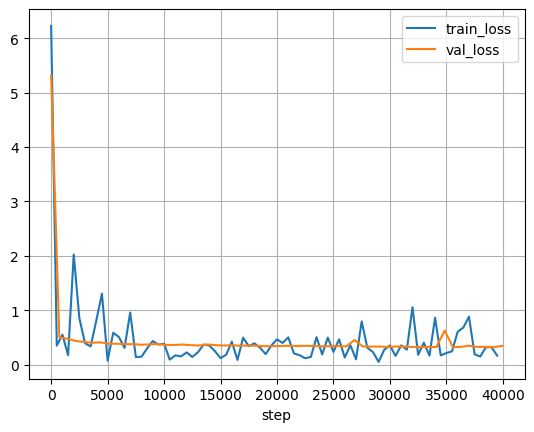

In [105]:
# 注意：回归任务的 MSE 损失不一定在 [0, 1] 区间内，纵轴范围由数据决定
def plot_learning_curves(record_dict, sample_step=500):
    """
    绘制学习曲线，对比训练集与验证集的损失随步数的变化趋势
    参数 record_dict (dict)：training() 函数返回的训练记录字典
        - 'train' (list)：每元素 {'loss': float, 'step': int}，训练集每步损失
        - 'val'   (list)：每元素 {'loss': float, 'step': int}，验证集每 eval_step 步损失
    参数 sample_step (int)：对训练集记录降采样的步长，避免图线过密，默认 500
                            验证集记录本身数量较少，不需要降采样
    """
    # pd.DataFrame(...)：将训练记录列表转为 DataFrame，列为 'loss' 和 'step'
    # .set_index("step")：将 step 列设为行索引，便于按步数绘图
    # .iloc[::sample_step]：按步长 sample_step 对训练记录降采样，减少绘图数据量
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 验证集记录较少（每 eval_step 步一条），无需降采样
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 遍历所有指标列（回归任务只有 'loss' 一列）
    for idx, item in enumerate(train_df.columns):
        # 绘制训练集损失曲线，横轴为全局训练步数
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制验证集损失曲线，与训练集对比可观察过拟合（val_loss 远高于 train_loss）
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()      # 显示网格线，便于读取具体数值
        plt.legend()    # 显示图例，区分训练和验证曲线
        # plt.xticks(...)  # （已注释）可自定义 x 轴刻度
        plt.xlabel("step")  # x 轴标签：训练步数

        plt.show()  # 渲染并显示图形

plot_learning_curves(record)  # 横坐标是 steps，传入训练记录字典绘制学习曲线

## 四、模型评估与测试

使用训练好的模型在测试集（5160 个样本）上进行最终评估，计算平均 MSE 损失以衡量模型泛化能力。

In [107]:
# evaluating：在测试集上计算平均 MSE 损失
# 参数 model：已训练好的回归神经网络
# 参数 test_loader：测试集 DataLoader（包含 5160 个样本，323 个批次）
# 参数 loss_fct：MSELoss 损失函数
# 返回值 loss (float)：测试集所有批次 MSE 损失的均值，越小说明模型泛化能力越好
loss = evaluating(model, test_loader, loss_fct,optimizer)
# f-string 格式化输出，:.4f 保留 4 位小数
print(f"loss:     {loss:.4f}")

loss:     0.3501
